## K-Means Clustering:

### Import Libraries:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

### Load Dataset:


In [4]:
customer_data = pd.read_csv('Mall_Customers.csv')


print(customer_data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


### Understand the Dataset:

In [5]:
#Dataset Shape
print("Dataset_shape:", customer_data.shape)

# Column Names
print(customer_data.columns)

#Dataset Information
print(customer_data.info())

#Missing values
print(customer_data.isnull().sum())



Dataset_shape: (200, 5)
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


## Select Features:
Annual Income (k$)
Spending Score (1-100)

In [9]:
X = customer_data[['Annual Income (k$)', 'Spending Score (1-100)']]

### Optimal Number of Clusters:

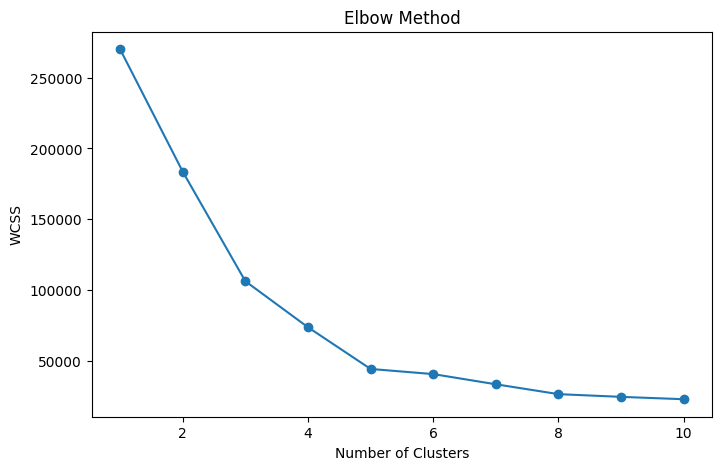

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

### Train K-Means Model:

In [11]:
#n_cluster=5
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

# Predict clusters
y_kmeans = kmeans.fit_predict(X)

### Visualize Customer Clusters:

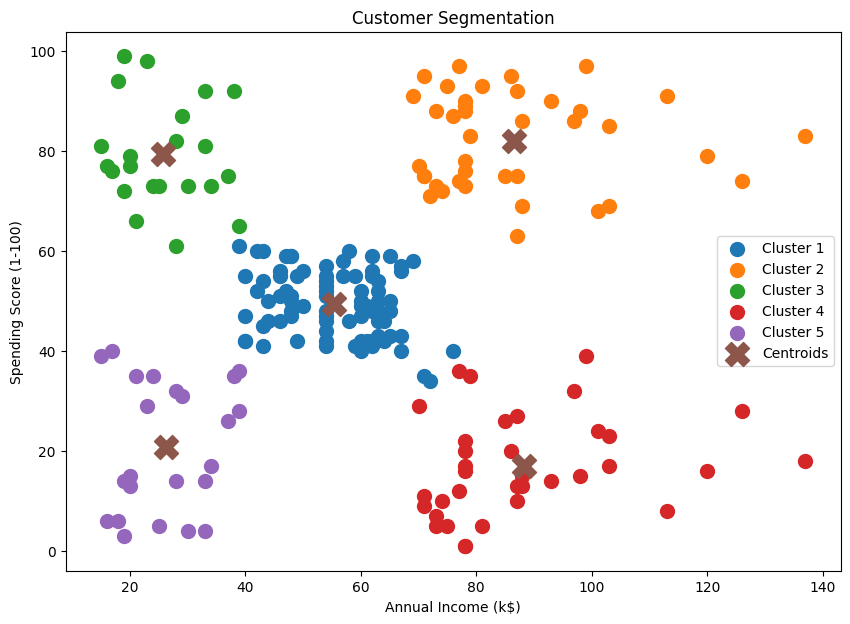

In [12]:
plt.figure(figsize=(10,7))

# Cluster 1
plt.scatter(
    X.iloc[y_kmeans == 0, 0],
    X.iloc[y_kmeans == 0, 1],
    s=100,
    label='Cluster 1'
)

# Cluster 2
plt.scatter(
    X.iloc[y_kmeans == 1, 0],
    X.iloc[y_kmeans == 1, 1],
    s=100,
    label='Cluster 2'
)

# Cluster 3
plt.scatter(
    X.iloc[y_kmeans == 2, 0],
    X.iloc[y_kmeans == 2, 1],
    s=100,
    label='Cluster 3'
)

# Cluster 4
plt.scatter(
    X.iloc[y_kmeans == 3, 0],
    X.iloc[y_kmeans == 3, 1],
    s=100,
    label='Cluster 4'
)

# Cluster 5
plt.scatter(
    X.iloc[y_kmeans == 4, 0],
    X.iloc[y_kmeans == 4, 1],
    s=100,
    label='Cluster 5'
)

# Centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    marker='X',
    label='Centroids'
)

plt.title('Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.legend()
plt.show()